In [1]:
import numpy as np
import pandas as pd
import random
import copy
import matplotlib.pyplot as plt

In [9]:
honey = pd.read_csv('honey.csv', sep=";")
weather = pd.read_csv('df_hourly_2019_2025.csv')
beehives = pd.read_csv('ule.csv', sep=";")

In [11]:
honey.head()

,year,week,honey,harvest
0,2019,30,66.0,1
1,2019,32,55.0,1
2,2019,33,134.0,2
3,2019,34,72.0,1
4,2019,35,59.0,1


In [10]:
weather.head()

,valid_time,temp,wspd,prcp,pres,week
0,2019-05-01 00:00:00,8.404327,3.310282,0.178814,941.63280,18
1,2019-05-01 01:00:00,8.166046,3.494877,0.156403,941.33044,18
2,2019-05-01 02:00:00,7.969513,3.636947,0.191212,941.26220,18
3,2019-05-01 03:00:00,7.678314,3.815005,0.128269,940.87940,18
4,2019-05-01 04:00:00,7.543060,3.679924,0.025272,940.96716,18


In [12]:
weather["year"] = pd.to_datetime(weather["valid_time"]).dt.year
weather["honey"] = np.nan
weather["harvest"] = np.nan

In [14]:
last_idx = weather.groupby(["year", "week"])["valid_time"].idxmax()

tmp = weather.loc[last_idx, ["year", "week"]].merge(
    honey,
    on=["year", "week"],
    how="left"
)

weather.loc[last_idx, "honey"] = tmp["honey"].values
weather.loc[last_idx, "harvest"] = tmp["harvest"].values

In [22]:
df = pd.merge(weather, beehives, on="year", how="inner")

In [23]:
df.head()

,valid_time,temp,wspd,prcp,pres,week,year,honey,harvest,beehive
0,2019-05-01 00:00:00,8.404327,3.310282,0.178814,941.63280,18,2019,NaN,NaN,92
1,2019-05-01 01:00:00,8.166046,3.494877,0.156403,941.33044,18,2019,NaN,NaN,92
2,2019-05-01 02:00:00,7.969513,3.636947,0.191212,941.26220,18,2019,NaN,NaN,92
3,2019-05-01 03:00:00,7.678314,3.815005,0.128269,940.87940,18,2019,NaN,NaN,92
4,2019-05-01 04:00:00,7.543060,3.679924,0.025272,940.96716,18,2019,NaN,NaN,92


Zakładamy, że wydajność pszczółki będzie zależeć od temperatury, prędkości wiatru, ilości opadu atmosferycznego, ciśnienia atmosferycznego oraz jej bazowej wydajności.

In [24]:
# parametry do późniejszej optymalizacji
params = {
    "temp_low": 10,
    "temp_high": 40,
    "temp_slope": 2.3,

    "wind_penalty": 0.3,

    "rain_penalty": 3.9,
    "rain_window": 20,

    "pres_penalty": 0.02,

    "base_efficiency": 1.0
}

In [25]:
def bee_efficiency(temp, wspd, prcp, pres, p):
    
    # jeżeli za ciepło lub za zimno - nie lata
    # załóżmy, że optymalna temperatura to 14 stopnie, a efektywność spada liniowo w miarę oddalania się od tej wartości
    
    temp_mid = (p["temp_low"] + p["temp_high"]) / 2
    temp_range = (p["temp_high"] - p["temp_low"]) / 2
    print(f"[debug] temp_range: {temp_range}")

    temp_eff = 1 - abs(temp - temp_mid) / temp_range
    temp_eff = np.clip(temp_eff, 0, 1)

    # if temp < p["temp_low"]:
    #     temp_eff = 0
    # elif temp > p["temp_high"]:
    #     temp_eff = 0
    # else:
    #     temp_eff = 1 - abs(temp - 14) / p["temp_slope"]
    #     temp_eff = max(0, temp_eff)

    # przy silnym wietrze pszczoły nie latają, zakładamy liniowy spadek efektywności wraz ze wzrostem prędkości wiatru
    wind_eff = 1 - p["wind_penalty"] * wspd
    wind_eff = np.clip(wind_eff, 0, 1)



    # taka sama logika przy opadach
    rain_eff = 1 - p["rain_penalty"] * prcp
    rain_eff = np.clip(rain_eff, 0, 1)

    pres_ref = 950
    pres_eff = 1 - p["pres_penalty"] * abs(pres - pres_ref)
    pres_eff = np.clip(pres_eff, 0, 1)


    eff = (0.45 * temp_eff + 0.20 * wind_eff + 0.25 * rain_eff +0.10 * pres_eff) #srednia wazona, zebysmy nie mialy tego problemu z zerem 
    eff = np.clip(eff, 0, 1)
    
    return eff

In [28]:
def simulate_honey(row, p):

    eff = bee_efficiency(
        row["temp"],
        row["wspd"],
        row["prcp"],
        row["pres"],
        p
    )

    # bazowa produkcja dla kolonii
    honey = (
        row["beehive"] *
        eff *
        p["base_efficiency"] 
        # row["harvest"]
    )

    return honey

In [29]:
def get_predictions(params_dict, df):
    preds = []

    for _, row in df.iterrows():
        preds.append(simulate_honey(row, params_dict))

    df = df.copy()
    df["pred"] = np.array(preds)

    return df

def to_weekly(df):
    weekly_pred = df.groupby(["year", "week"])["pred"].sum().reset_index()

    return weekly_pred

def get_weekly_true(df):
    weekly_true = df[["year", "week", "honey"]].dropna()

    weekly_true = weekly_true.groupby(["year", "week"], as_index=False).first()

    return weekly_true

In [35]:
def loss(params_dict, df):

    # 1. predykcje hourly
    df_pred = get_predictions(params_dict, df)

    # 2. agregacja weekly
    weekly_pred = to_weekly(df_pred)

    # 3. true values
    weekly_true = get_weekly_true(df)

    # 4. merge
    merged = weekly_true.merge(weekly_pred, on=["year", "week"], how="inner")

    # 5. RMSE
    rmse = np.sqrt(np.mean((merged["honey"] - merged["pred"]) ** 2))

    return rmse

In [36]:
bee = {
    "temp_low": 11,
    "temp_high": 31,
    "temp_slope": 2.1,
    "wind_penalty": 0.25,
    "rain_penalty": 4.2,
    "pres_penalty": 0.015,
    "base_efficiency": 1.05
}

In [37]:
def fitness(bee_params):
    return loss(bee_params, df)

In [38]:
def random_bee():
    return {
        "temp_low": random.uniform(6, 10),
        "temp_high": random.uniform(20, 25),
        "temp_slope": random.uniform(0.5, 5.0),
        "wind_penalty": random.uniform(0.0, 1.0),
        "rain_penalty": random.uniform(0.0, 8.0),
        "pres_penalty": random.uniform(0.0, 0.05),
        "base_efficiency": random.uniform(0.5, 1.5)
    }

population = [random_bee() for _ in range(100)]

def mutate(bee):
    new_bee = copy.deepcopy(bee)

    key = random.choice(list(bee.keys()))
    new_bee[key] += random.uniform(-0.2, 0.2)

    return new_bee

def run_opt(iterations=100):

    global population

    for _ in range(iterations):

        for i in range(len(population)):

            candidate = mutate(population[i])

            if fitness(candidate) < fitness(population[i]):
                population[i] = candidate

    return min(population, key=fitness)

In [40]:
best_bee = run_opt(iterations=1)
best_rmse = loss(best_bee, df)
print('Najlepsze parametry:')
print(best_bee)
print(f'RMSE = {best_rmse:.4f}')

df['predicted_honey_best'] = df.apply(lambda row: simulate_honey(row, best_bee), axis=1)
df[['year', 'week', 'honey', 'predicted_honey_best']].head(15)

[debug] temp_range: 7.1902281534106685
[debug] temp_range: 7.1902281534106685
[debug] temp_range: 7.1902281534106685
[debug] temp_range: 7.1902281534106685
[debug] temp_range: 7.1902281534106685
[debug] temp_range: 7.1902281534106685
[debug] temp_range: 7.1902281534106685
[debug] temp_range: 7.1902281534106685
[debug] temp_range: 7.1902281534106685
[debug] temp_range: 7.1902281534106685
[debug] temp_range: 7.1902281534106685
[debug] temp_range: 7.1902281534106685
[debug] temp_range: 7.1902281534106685
[debug] temp_range: 7.1902281534106685
[debug] temp_range: 7.1902281534106685
[debug] temp_range: 7.1902281534106685
[debug] temp_range: 7.1902281534106685
[debug] temp_range: 7.1902281534106685
[debug] temp_range: 7.1902281534106685
[debug] temp_range: 7.1902281534106685
[debug] temp_range: 7.1902281534106685
[debug] temp_range: 7.1902281534106685
[debug] temp_range: 7.1902281534106685
[debug] temp_range: 7.1902281534106685
[debug] temp_range: 7.1902281534106685
[debug] temp_range: 7.190

KeyboardInterrupt: 

In [ ]:
print('Najlepsze parametry:')
print(best_bee)
print(f'RMSE = {best_rmse:.4f}')

Najlepsze parametry:
{'temp_low': 6.419349778306975, 'temp_high': 19.62405081767822, 'temp_slope': 3.8882558767525586, 'wind_penalty': -0.12666327522038567, 'rain_penalty': -0.11373957615100011, 'pres_penalty': -0.059464618469573696, 'base_efficiency': 1.4737018623421179}
RMSE = 76.0929


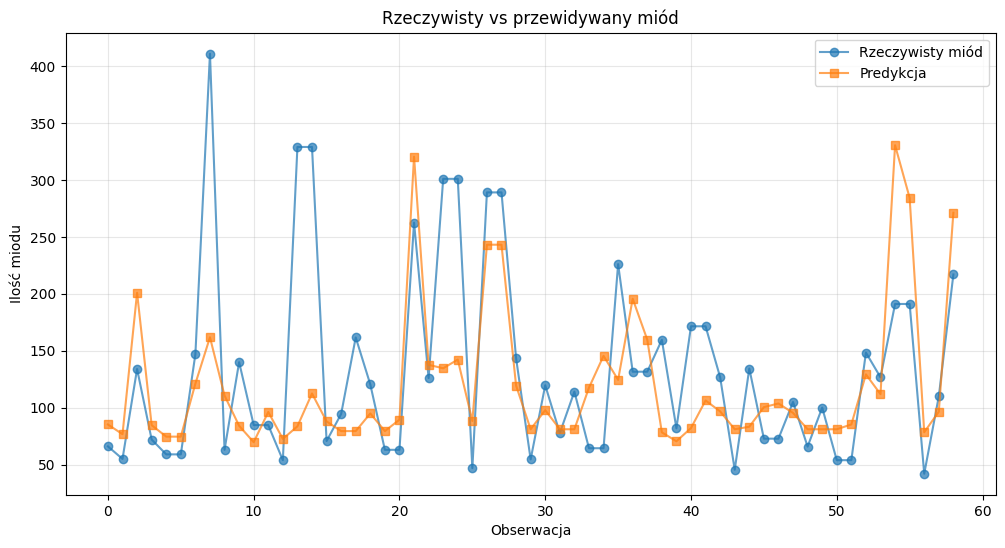

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df["honey"].values, label="Rzeczywisty miód", marker='o', alpha=0.7)
plt.plot(df["predicted_honey_best"].values, label="Predykcja", marker='s', alpha=0.7)
plt.legend()
plt.title("Rzeczywisty vs przewidywany miód")
plt.xlabel("Obserwacja")
plt.ylabel("Ilość miodu")
plt.grid(True, alpha=0.3)
plt.show()

{'temp_low': 6.338347696149941, 'temp_high': 22.908862499323767, 'temp_slope': 3.8024400255508324, 'wind_penalty': -0.014338742702168422, 'rain_penalty': -0.01074672187225656, 'pres_penalty': -0.013460314012872648, 'base_efficiency': 1.2513008938110284}
RMSE = 78.8268

In [ ]:
# najlepszy wynik z run_opt

{'temp_low': 9.160728007762975, 'temp_high': 24.49404711270679, 'temp_slope': 43.35895073491914, 'wind_penalty': -0.3670792426740751, 'rain_penalty': -1.2448320056154039, 'pres_penalty': -0.00013839921508588746, 'base_efficiency': 0.4877893795676532}
RMSE = 68.1048

In [ ]:
{'temp_low': 9.160728007762975, 'temp_high': 24.49404711270679, 'temp_slope': 19.16652515079757, 'wind_penalty': -0.23988570198499704, 'rain_penalty': -1.0159632323437868, 'pres_penalty': -0.00013839921508588746, 'base_efficiency': 0.6871523057723211}
RMSE = 70.3003

In [ ]:
# best_params = {
#     'temp_low': 6.338347696149941,
#     'temp_high': 22.908862499323767,
#     'temp_slope': 3.8024400255508324,
#     'wind_penalty': -0.014338742702168422,
#     'rain_penalty': -0.01074672187225656,
#     'pres_penalty': -0.013460314012872648,
#     'base_efficiency': 1.25130089938110284
# }

best_params = {
    'temp_low': 6.419349778306975,
    'temp_high': 19.62405081767822,
    'temp_slope': 3.8882558767525586,
    'wind_penalty': -0.12666327522038567,
    'rain_penalty': -0.11373957615100011,
    'pres_penalty': -0.059464618469573696,
    'base_efficiency': 1.4737018623421179
}



In [ ]:
import numpy as np
import pandas as pd

df_results = df.copy()

df_results["prediction"] = df_results.apply(
    lambda row: simulate_honey(row, best_params),
    axis=1
)

df_results["difference"] = df_results["prediction"] - df_results["honey"]
df_results["absolute_error"] = abs(df_results["difference"])

df_results["error_percent"] = (
    df_results["absolute_error"] / df_results["honey"] * 100
)

df_results["accuracy_percent"] = 100 - df_results["error_percent"]
df_results["accuracy_percent"] = df_results["accuracy_percent"].clip(lower=0)

[debug] temp_range: 6.602350519685623
[debug] temp_range: 6.602350519685623
[debug] temp_range: 6.602350519685623
[debug] temp_range: 6.602350519685623
[debug] temp_range: 6.602350519685623
[debug] temp_range: 6.602350519685623
[debug] temp_range: 6.602350519685623
[debug] temp_range: 6.602350519685623
[debug] temp_range: 6.602350519685623
[debug] temp_range: 6.602350519685623
[debug] temp_range: 6.602350519685623
[debug] temp_range: 6.602350519685623
[debug] temp_range: 6.602350519685623
[debug] temp_range: 6.602350519685623
[debug] temp_range: 6.602350519685623
[debug] temp_range: 6.602350519685623
[debug] temp_range: 6.602350519685623
[debug] temp_range: 6.602350519685623
[debug] temp_range: 6.602350519685623
[debug] temp_range: 6.602350519685623
[debug] temp_range: 6.602350519685623
[debug] temp_range: 6.602350519685623
[debug] temp_range: 6.602350519685623
[debug] temp_range: 6.602350519685623
[debug] temp_range: 6.602350519685623
[debug] temp_range: 6.602350519685623
[debug] temp

In [ ]:
harvest_table = df_results[[
    "year",
    "week",
    "harvest",
    "honey",
    "prediction",
    "difference",
    "absolute_error",
    "error_percent",
    "accuracy_percent"
]].copy()

harvest_table = harvest_table.rename(columns={
    "honey": "actual_honey"
})

harvest_table = harvest_table.round(2)

harvest_table

,year,week,harvest,actual_honey,prediction,difference,absolute_error,error_percent,accuracy_percent
0,2019,30,1,66.0,85.24,19.24,19.24,29.16,70.84
1,2019,32,1,55.0,76.75,21.75,21.75,39.55,60.45
2,2019,33,2,134.0,200.94,66.94,66.94,49.95,50.05
3,2019,34,1,72.0,84.63,12.63,12.63,17.55,82.45
4,2019,35,1,59.0,74.57,15.57,15.57,26.39,73.61
5,2019,35,1,59.0,74.57,15.57,15.57,26.39,73.61
6,2019,36,1,147.0,121.13,-25.87,25.87,17.60,82.40
7,2020,26,2,410.9,161.85,-249.05,249.05,60.61,39.39
8,2020,29,1,63.0,110.66,47.66,47.66,75.65,24.35
9,2020,30,1,140.0,84.10,-55.90,55.90,39.93,60.07


In [ ]:
yearly_table = (
    df_results
    .groupby("year", as_index=False)
    .agg(
        actual_honey=("honey", "sum"),
        predicted_honey=("prediction", "sum")
    )
)

yearly_table["difference"] = yearly_table["predicted_honey"] - yearly_table["actual_honey"]
yearly_table["absolute_error"] = abs(yearly_table["difference"])

yearly_table["error_percent"] = (
    yearly_table["absolute_error"] / yearly_table["actual_honey"] * 100
)

yearly_table["accuracy_percent"] = 100 - yearly_table["error_percent"]
yearly_table["accuracy_percent"] = yearly_table["accuracy_percent"].clip(lower=0)

yearly_table = yearly_table.round(2)

yearly_table

,year,actual_honey,predicted_honey,difference,absolute_error,error_percent,accuracy_percent
0,2019,592.0,717.84,125.84,125.84,21.26,78.74
1,2020,1495.2,791.27,-703.93,703.93,47.08,52.92
2,2021,1563.8,1245.71,-318.09,318.09,20.34,79.66
3,2022,1489.6,1422.57,-67.03,67.03,4.50,95.50
4,2023,847.7,692.70,-155.00,155.00,18.28,81.72
5,2024,979.3,1018.38,39.08,39.08,3.99,96.01
6,2025,877.8,1172.86,295.06,295.06,33.61,66.39
